In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

import joblib

In [3]:
df = pd.read_csv(
    "../data/processed/feature_engineered_data.csv"
)

print("Dataset Shape :", df.shape)

df.head()

Dataset Shape : (120000, 61)


,admission_id,patient_id,hospital_id,admit_type,ward_type,los_days,readmitted_30d,age,gender,patient_state,...,age_cost,diagnosis_cost,teaching_long_stay,has_cardiovascular,has_respiratory,has_neurological,has_endocrine,has_infectious,has_neoplasm,has_gastrointestinal
0,bcb311d6-0808-498f-8ae1-11abe1fbc08e,6960d399-8398-4db4-9a90-0b329b81bc2b,b22e7b51-2ea6-4611-a8e5-d3d24ec779d8,Elective,General,4,0,46,M,Haryana,...,850632,18492,0,0,0,0,1,0,0,0
1,996ac6db-a192-46a0-b536-503a1c57994b,ec1999d4-f097-4881-91a5-6f9b1f8dac78,8b1e01b7-9f0e-413f-b330-454d271a5c6e,OPD,General,1,0,31,M,Andhra Pradesh,...,31031,1001,0,0,1,0,0,0,0,0
2,cc4849fa-b740-487b-beda-3086a18273c0,ed56abac-a0ba-44db-a816-b5da4183b9b5,eae7c9ec-65c8-4d48-92f3-7da7b3e2b227,Emergency,General,5,1,53,F,West Bengal,...,3163888,179088,0,1,0,1,0,1,0,0
3,b38cdd03-165c-428c-b221-9f1d4cf8bdeb,90c335d5-dd71-46c8-acd2-656653f421c6,df4431ea-1acf-4e77-963c-6173e9787151,Emergency,ICU,11,1,56,F,Kerala,...,4064928,72588,0,1,0,0,0,0,0,0
4,6a154ec0-92cc-43f5-ada5-ede0a600ce9e,694988e8-9ef5-43e8-aefe-c6b98b1e96fe,8b1e01b7-9f0e-413f-b330-454d271a5c6e,Emergency,General,5,1,69,F,Kerala,...,656190,28530,0,0,1,0,0,0,1,1


In [4]:
print(df.info())

print()

print(df["readmitted_30d"].value_counts())

print()

print(df["readmitted_30d"].value_counts(normalize=True))

<class 'pandas.DataFrame'>
RangeIndex: 120000 entries, 0 to 119999
Data columns (total 61 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   admission_id              120000 non-null  str    
 1   patient_id                120000 non-null  str    
 2   hospital_id               120000 non-null  str    
 3   admit_type                120000 non-null  str    
 4   ward_type                 120000 non-null  str    
 5   los_days                  120000 non-null  int64  
 6   readmitted_30d            120000 non-null  int64  
 7   age                       120000 non-null  int64  
 8   gender                    120000 non-null  str    
 9   patient_state             120000 non-null  str    
 10  insurance_type            120000 non-null  str    
 11  hospital_name             120000 non-null  str    
 12  hospital_state            120000 non-null  str    
 13  hospital_tier             120000 non-null  str    
 14 

In [5]:
identifier_columns = [

    "admission_id",
    "patient_id",
    "hospital_id"

]

text_columns = [

    "hospital_name",
    "primary_diagnosis",
    "diagnosis_list",
    "diagnosis_categories"

]

target_column = "readmitted_30d"

X = df.drop(
    columns=identifier_columns +
            text_columns +
            [target_column]
)

y = df[target_column]

print("Feature Matrix :", X.shape)

print("Target :", y.shape)

Feature Matrix : (120000, 53)
Target : (120000,)


In [6]:
print(X.columns.tolist())

['admit_type', 'ward_type', 'los_days', 'age', 'gender', 'patient_state', 'insurance_type', 'hospital_state', 'hospital_tier', 'beds', 'teaching', 'primary_diag_category', 'total_diagnoses', 'cost_category', 'total_cost_inr', 'admit_year', 'admit_month', 'admit_day', 'admit_weekday', 'admit_quarter', 'discharge_year', 'discharge_month', 'weekend_admission', 'stay_per_bed', 'cost_per_day', 'cost_per_bed', 'num_diagnosis_categories', 'diagnosis_density', 'cost_per_diagnosis', 'diagnosis_per_bed', 'elderly', 'very_elderly', 'long_stay', 'very_long_stay', 'multiple_diagnoses', 'age_diagnosis', 'large_hospital', 'low_cost', 'high_cost', 'bed_cost_ratio', 'bed_los_ratio', 'season', 'age_los', 'age_cost', 'diagnosis_cost', 'teaching_long_stay', 'has_cardiovascular', 'has_respiratory', 'has_neurological', 'has_endocrine', 'has_infectious', 'has_neoplasm', 'has_gastrointestinal']


In [7]:
print(X.dtypes)

admit_type                      str
ward_type                       str
los_days                      int64
age                           int64
gender                          str
patient_state                   str
insurance_type                  str
hospital_state                  str
hospital_tier                   str
beds                          int64
teaching                      int64
primary_diag_category           str
total_diagnoses               int64
cost_category                   str
total_cost_inr                int64
admit_year                    int64
admit_month                   int64
admit_day                     int64
admit_weekday                   str
admit_quarter                 int64
discharge_year                int64
discharge_month               int64
weekend_admission             int64
stay_per_bed                float64
cost_per_day                float64
cost_per_bed                float64
num_diagnosis_categories      int64
diagnosis_density           

In [8]:
print(X.head())

  admit_type ward_type  los_days  age gender   patient_state insurance_type  \
0   Elective   General         4   46      M         Haryana            ESI   
1        OPD   General         1   31      M  Andhra Pradesh        Unknown   
2  Emergency   General         5   53      F     West Bengal        Private   
3  Emergency       ICU        11   56      F          Kerala        Unknown   
4  Emergency   General         5   69      F          Kerala        Unknown   

   hospital_state hospital_tier  beds  ...  age_cost diagnosis_cost  \
0          Odisha         tier2   359  ...    850632          18492   
1  Madhya Pradesh         tier3    67  ...     31031           1001   
2       Karnataka         tier1  1018  ...   3163888         179088   
3   Uttar Pradesh         tier3   191  ...   4064928          72588   
4  Madhya Pradesh         tier3    67  ...    656190          28530   

   teaching_long_stay has_cardiovascular  has_respiratory  has_neurological  \
0                  

In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Set :", X_train.shape)
print("Testing Set  :", X_test.shape)

print("\nTraining Target Distribution")
print(y_train.value_counts(normalize=True))

print("\nTesting Target Distribution")
print(y_test.value_counts(normalize=True))

Training Set : (96000, 53)
Testing Set  : (24000, 53)

Training Target Distribution
readmitted_30d
0    0.881583
1    0.118417
Name: proportion, dtype: float64

Testing Target Distribution
readmitted_30d
0    0.881583
1    0.118417
Name: proportion, dtype: float64


In [10]:
categorical_features = X_train.select_dtypes(
    include=["object", "string"]
).columns.tolist()

numerical_features = X_train.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

print("Categorical Features")

for feature in categorical_features:
    print(feature)

print("\n")

print("Numerical Features")

for feature in numerical_features:
    print(feature)

Categorical Features
admit_type
ward_type
gender
patient_state
insurance_type
hospital_state
hospital_tier
primary_diag_category
cost_category
admit_weekday
season


Numerical Features
los_days
age
beds
teaching
total_diagnoses
total_cost_inr
admit_year
admit_month
admit_day
admit_quarter
discharge_year
discharge_month
weekend_admission
stay_per_bed
cost_per_day
cost_per_bed
num_diagnosis_categories
diagnosis_density
cost_per_diagnosis
diagnosis_per_bed
elderly
very_elderly
long_stay
very_long_stay
multiple_diagnoses
age_diagnosis
large_hospital
low_cost
high_cost
bed_cost_ratio
bed_los_ratio
age_los
age_cost
diagnosis_cost
teaching_long_stay
has_cardiovascular
has_respiratory
has_neurological
has_endocrine
has_infectious
has_neoplasm
has_gastrointestinal


In [11]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.impute import SimpleImputer

# Numerical Pipeline
numeric_transformer = Pipeline(

    steps=[

        ("imputer", SimpleImputer(strategy="median")),

        ("scaler", StandardScaler())

    ]

)

# Categorical Pipeline
categorical_transformer = Pipeline(

    steps=[

        ("imputer", SimpleImputer(strategy="most_frequent")),

        ("encoder", OneHotEncoder(handle_unknown="ignore"))

    ]

)

# Complete Preprocessor
preprocessor = ColumnTransformer(

    transformers=[

        ("num",
         numeric_transformer,
         numerical_features),

        ("cat",
         categorical_transformer,
         categorical_features)

    ]

)

print("Preprocessing pipeline created successfully.")

Preprocessing pipeline created successfully.


In [12]:
X_train_processed = preprocessor.fit_transform(X_train)

X_test_processed = preprocessor.transform(X_test)

print("Training Data Shape :", X_train_processed.shape)
print("Testing Data Shape  :", X_test_processed.shape)

Training Data Shape : (96000, 115)
Testing Data Shape  : (24000, 115)


Baseline Logistic Regression

In [13]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(
    random_state=42,
    max_iter=1000
)

lr.fit(X_train_processed, y_train)

lr_predictions = lr.predict(X_test_processed)

lr_probabilities = lr.predict_proba(X_test_processed)[:, 1]

print("Logistic Regression trained successfully.")

Logistic Regression trained successfully.


In [14]:

print("LOGISTIC REGRESSION RESULTS")

print(f"Accuracy : {accuracy_score(y_test, lr_predictions):.4f}")

print(f"Precision: {precision_score(y_test, lr_predictions):.4f}")

print(f"Recall   : {recall_score(y_test, lr_predictions):.4f}")

print(f"F1 Score : {f1_score(y_test, lr_predictions):.4f}")

print(f"ROC AUC  : {roc_auc_score(y_test, lr_probabilities):.4f}")

print("\nConfusion Matrix")

print(confusion_matrix(y_test, lr_predictions))

print("\nClassification Report")

print(classification_report(y_test, lr_predictions))

LOGISTIC REGRESSION RESULTS
Accuracy : 0.8840
Precision: 0.6183
Recall   : 0.0524
F1 Score : 0.0967
ROC AUC  : 0.7487

Confusion Matrix
[[21066    92]
 [ 2693   149]]

Classification Report


              precision    recall  f1-score   support

           0       0.89      1.00      0.94     21158
           1       0.62      0.05      0.10      2842

    accuracy                           0.88     24000
   macro avg       0.75      0.52      0.52     24000
weighted avg       0.85      0.88      0.84     24000



In [15]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)

rf.fit(X_train_processed, y_train)

print("Random Forest trained successfully.")

Random Forest trained successfully.


In [16]:
rf_predictions = rf.predict(X_test_processed)

rf_probabilities = rf.predict_proba(X_test_processed)[:, 1]

print("Predictions generated successfully.")

Predictions generated successfully.


In [17]:

print("RANDOM FOREST RESULTS")


print(f"Accuracy : {accuracy_score(y_test, rf_predictions):.4f}")

print(f"Precision: {precision_score(y_test, rf_predictions):.4f}")

print(f"Recall   : {recall_score(y_test, rf_predictions):.4f}")

print(f"F1 Score : {f1_score(y_test, rf_predictions):.4f}")

print(f"ROC AUC  : {roc_auc_score(y_test, rf_probabilities):.4f}")

print("\nConfusion Matrix")

print(confusion_matrix(y_test, rf_predictions))

print("\nClassification Report")

print(classification_report(y_test, rf_predictions))

RANDOM FOREST RESULTS
Accuracy : 0.8739
Precision: 0.4245
Recall   : 0.1830
F1 Score : 0.2557
ROC AUC  : 0.7295

Confusion Matrix
[[20453   705]
 [ 2322   520]]

Classification Report
              precision    recall  f1-score   support

           0       0.90      0.97      0.93     21158
           1       0.42      0.18      0.26      2842

    accuracy                           0.87     24000
   macro avg       0.66      0.57      0.59     24000
weighted avg       0.84      0.87      0.85     24000



In [18]:
comparison = pd.DataFrame({

    "Model": [
        "Logistic Regression",
        "Random Forest"
    ],

    "Accuracy": [
        accuracy_score(y_test, lr_predictions),
        accuracy_score(y_test, rf_predictions)
    ],

    "Precision": [
        precision_score(y_test, lr_predictions),
        precision_score(y_test, rf_predictions)
    ],

    "Recall": [
        recall_score(y_test, lr_predictions),
        recall_score(y_test, rf_predictions)
    ],

    "F1 Score": [
        f1_score(y_test, lr_predictions),
        f1_score(y_test, rf_predictions)
    ],

    "ROC AUC": [
        roc_auc_score(y_test, lr_probabilities),
        roc_auc_score(y_test, rf_probabilities)
    ]

})

comparison = comparison.round(4)

comparison

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Logistic Regression,0.8840,0.6183,0.0524,0.0967,0.7487
1,Random Forest,0.8739,0.4245,0.1830,0.2557,0.7295


In [19]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

print(scale_pos_weight)

7.44475721323012


In [20]:
from xgboost import XGBClassifier

xgb = XGBClassifier(

    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric="logloss",
    n_jobs=-1

)

xgb.fit(

    X_train_processed,
    y_train

)

print("XGBoost trained successfully.")

XGBoost trained successfully.


In [21]:
xgb_predictions = xgb.predict(X_test_processed)

xgb_probabilities = xgb.predict_proba(X_test_processed)[:,1]

print("Predictions generated successfully.")

Predictions generated successfully.


In [22]:

print("XGBOOST RESULTS")

print(f"Accuracy : {accuracy_score(y_test, xgb_predictions):.4f}")

print(f"Precision: {precision_score(y_test, xgb_predictions):.4f}")

print(f"Recall   : {recall_score(y_test, xgb_predictions):.4f}")

print(f"F1 Score : {f1_score(y_test, xgb_predictions):.4f}")

print(f"ROC AUC  : {roc_auc_score(y_test, xgb_probabilities):.4f}")

print("\nConfusion Matrix")

print(confusion_matrix(y_test, xgb_predictions))

print("\nClassification Report")

print(classification_report(y_test, xgb_predictions))

XGBOOST RESULTS
Accuracy : 0.7319
Precision: 0.2450
Recall   : 0.6073
F1 Score : 0.3491
ROC AUC  : 0.7411

Confusion Matrix
[[15839  5319]
 [ 1116  1726]]

Classification Report
              precision    recall  f1-score   support

           0       0.93      0.75      0.83     21158
           1       0.24      0.61      0.35      2842

    accuracy                           0.73     24000
   macro avg       0.59      0.68      0.59     24000
weighted avg       0.85      0.73      0.77     24000



In [23]:
comparison = pd.DataFrame({

    "Model":[

        "Logistic Regression",
        "Random Forest",
        "XGBoost"

    ],

    "Accuracy":[

        accuracy_score(y_test, lr_predictions),
        accuracy_score(y_test, rf_predictions),
        accuracy_score(y_test, xgb_predictions)

    ],

    "Precision":[

        precision_score(y_test, lr_predictions),
        precision_score(y_test, rf_predictions),
        precision_score(y_test, xgb_predictions)

    ],

    "Recall":[

        recall_score(y_test, lr_predictions),
        recall_score(y_test, rf_predictions),
        recall_score(y_test, xgb_predictions)

    ],

    "F1 Score":[

        f1_score(y_test, lr_predictions),
        f1_score(y_test, rf_predictions),
        f1_score(y_test, xgb_predictions)

    ],

    "ROC AUC":[

        roc_auc_score(y_test, lr_probabilities),
        roc_auc_score(y_test, rf_probabilities),
        roc_auc_score(y_test, xgb_probabilities)

    ]

})

comparison = comparison.round(4)

comparison

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Logistic Regression,0.8840,0.6183,0.0524,0.0967,0.7487
1,Random Forest,0.8739,0.4245,0.1830,0.2557,0.7295
2,XGBoost,0.7319,0.2450,0.6073,0.3491,0.7411


In [24]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

In [25]:
!pip install lightgbm
from lightgbm import LGBMClassifier

lgbm = LGBMClassifier(

    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    n_jobs=-1
)

lgbm.fit(
    X_train_processed,
    y_train
)

print("LightGBM trained successfully.")

[LightGBM] [Info] Number of positive: 11368, number of negative: 84632
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.038899 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3516
[LightGBM] [Info] Number of data points in the train set: 96000, number of used features: 114
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.118417 -> initscore=-2.007510
[LightGBM] [Info] Start training from score -2.007510
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive ga

In [26]:
lgbm_predictions = lgbm.predict(X_test_processed)

lgbm_probabilities = lgbm.predict_proba(X_test_processed)[:, 1]

print("Predictions generated successfully.")

Predictions generated successfully.


In [27]:

print("LIGHTGBM RESULTS")

print(f"Accuracy : {accuracy_score(y_test, lgbm_predictions):.4f}")

print(f"Precision: {precision_score(y_test, lgbm_predictions):.4f}")

print(f"Recall   : {recall_score(y_test, lgbm_predictions):.4f}")

print(f"F1 Score : {f1_score(y_test, lgbm_predictions):.4f}")

print(f"ROC AUC  : {roc_auc_score(y_test, lgbm_probabilities):.4f}")

print("\nConfusion Matrix")

print(confusion_matrix(y_test, lgbm_predictions))

print("\nClassification Report")

print(classification_report(y_test, lgbm_predictions))

LIGHTGBM RESULTS
Accuracy : 0.7150
Precision: 0.2382
Recall   : 0.6400
F1 Score : 0.3472
ROC AUC  : 0.7438

Confusion Matrix
[[15340  5818]
 [ 1023  1819]]

Classification Report
              precision    recall  f1-score   support

           0       0.94      0.73      0.82     21158
           1       0.24      0.64      0.35      2842

    accuracy                           0.71     24000
   macro avg       0.59      0.68      0.58     24000
weighted avg       0.85      0.71      0.76     24000



In [28]:
comparison = pd.DataFrame({

    "Model": [
        "Logistic Regression",
        "Random Forest",
        "XGBoost",
        "LightGBM"
    ],

    "Accuracy": [
        accuracy_score(y_test, lr_predictions),
        accuracy_score(y_test, rf_predictions),
        accuracy_score(y_test, xgb_predictions),
        accuracy_score(y_test, lgbm_predictions)
    ],

    "Precision": [
        precision_score(y_test, lr_predictions),
        precision_score(y_test, rf_predictions),
        precision_score(y_test, xgb_predictions),
        precision_score(y_test, lgbm_predictions)
    ],

    "Recall": [
        recall_score(y_test, lr_predictions),
        recall_score(y_test, rf_predictions),
        recall_score(y_test, xgb_predictions),
        recall_score(y_test, lgbm_predictions)
    ],

    "F1 Score": [
        f1_score(y_test, lr_predictions),
        f1_score(y_test, rf_predictions),
        f1_score(y_test, xgb_predictions),
        f1_score(y_test, lgbm_predictions)
    ],

    "ROC AUC": [
        roc_auc_score(y_test, lr_probabilities),
        roc_auc_score(y_test, rf_probabilities),
        roc_auc_score(y_test, xgb_probabilities),
        roc_auc_score(y_test, lgbm_probabilities)
    ]

})

comparison = comparison.round(4)

comparison

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Logistic Regression,0.8840,0.6183,0.0524,0.0967,0.7487
1,Random Forest,0.8739,0.4245,0.1830,0.2557,0.7295
2,XGBoost,0.7319,0.2450,0.6073,0.3491,0.7411
3,LightGBM,0.7150,0.2382,0.6400,0.3472,0.7438


In [29]:
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from lightgbm import LGBMClassifier
from sklearn.model_selection import StratifiedKFold

# Base LightGBM model
lgbm = LGBMClassifier(
    objective="binary",
    metric="auc",
    random_state=42,
    n_jobs=-1
)

# Hyperparameter search space
param_grid = {

    "n_estimators": [200, 300, 500, 700],

    "learning_rate": [0.005, 0.01, 0.02, 0.03, 0.05],

    "max_depth": [6, 8, 10, -1],

    "num_leaves": [31, 63, 95, 127],

    "min_child_samples": [10, 20, 30],

    "subsample": [0.8, 0.9, 1.0],

    "colsample_bytree": [0.8, 0.9, 1.0],

    "reg_alpha": [0, 0.1, 0.5],

    "reg_lambda": [0, 0.1, 0.5],

    "min_split_gain": [0, 0.1, 0.3],
    "scale_pos_weight": [5,6,7,7.44,8,9,10],
    "min_child_weight":[1e-3,1e-2,0.1,1]
}

# Randomized Search
random_search = RandomizedSearchCV(
    estimator=lgbm,
    param_distributions=param_grid,
    n_iter=30,
    scoring="f1",
    cv=StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=42
    ),
    random_state=42,
    n_jobs=-1,
    verbose=2
)

random_search.fit(
    X_train_processed,
    y_train
)

print("\nHyperparameter tuning completed successfully.")

Fitting 5 folds for each of 30 candidates, totalling 150 fits
[LightGBM] [Info] Number of positive: 11368, number of negative: 84632
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.021776 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3516
[LightGBM] [Info] Number of data points in the train set: 96000, number of used features: 114
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.118417 -> initscore=-2.007510
[LightGBM] [Info] Start training from score -2.007510

Hyperparameter tuning completed successfully.


In [30]:
print("Best Parameters:\n")

print(random_search.best_params_)

print("\n")

print("Best Cross Validation F1 Score:")

print(random_search.best_score_)

Best Parameters:

{'subsample': 0.9, 'scale_pos_weight': 5, 'reg_lambda': 0.1, 'reg_alpha': 0, 'num_leaves': 63, 'n_estimators': 700, 'min_split_gain': 0, 'min_child_weight': 1, 'min_child_samples': 10, 'max_depth': -1, 'learning_rate': 0.01, 'colsample_bytree': 0.8}


Best Cross Validation F1 Score:
0.35297364511495033


In [31]:
best_lgbm = random_search.best_estimator_
print(best_lgbm)
joblib.dump(best_lgbm, "../models/lightgbm_model.pkl")
joblib.dump(preprocessor, "../models/preprocessor.pkl")

LGBMClassifier(colsample_bytree=0.8, learning_rate=0.01, metric='auc',
               min_child_samples=10, min_child_weight=1, min_split_gain=0,
               n_estimators=700, n_jobs=-1, num_leaves=63, objective='binary',
               random_state=42, reg_alpha=0, reg_lambda=0.1, scale_pos_weight=5,
               subsample=0.9)


['../models/preprocessor.pkl']

In [32]:
best_predictions = best_lgbm.predict(X_test_processed)

best_probabilities = best_lgbm.predict_proba(X_test_processed)[:, 1]

print("TUNED LIGHTGBM RESULTS")

print(f"Accuracy : {accuracy_score(y_test, best_predictions):.4f}")
print(f"Precision: {precision_score(y_test, best_predictions):.4f}")
print(f"Recall   : {recall_score(y_test, best_predictions):.4f}")
print(f"F1 Score : {f1_score(y_test, best_predictions):.4f}")
print(f"ROC AUC  : {roc_auc_score(y_test, best_probabilities):.4f}")

print("\nConfusion Matrix")
print(confusion_matrix(y_test, best_predictions))

print("\nClassification Report")
print(classification_report(y_test, best_predictions))

TUNED LIGHTGBM RESULTS
Accuracy : 0.8000
Precision: 0.2923
Recall   : 0.4849
F1 Score : 0.3647
ROC AUC  : 0.7459

Confusion Matrix
[[17822  3336]
 [ 1464  1378]]

Classification Report
              precision    recall  f1-score   support

           0       0.92      0.84      0.88     21158
           1       0.29      0.48      0.36      2842

    accuracy                           0.80     24000
   macro avg       0.61      0.66      0.62     24000
weighted avg       0.85      0.80      0.82     24000



In [33]:
import numpy as np
import pandas as pd

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    accuracy_score
)

In [34]:
thresholds = np.arange(0.10, 0.91, 0.05)

results = []

for threshold in thresholds:

    predictions = (best_probabilities >= threshold).astype(int)

    accuracy = accuracy_score(y_test, predictions)

    precision = precision_score(
        y_test,
        predictions,
        zero_division=0
    )

    recall = recall_score(
        y_test,
        predictions,
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        predictions,
        zero_division=0
    )

    results.append([
        threshold,
        accuracy,
        precision,
        recall,
        f1
    ])

threshold_results = pd.DataFrame(
    results,
    columns=[
        "Threshold",
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ]
)

threshold_results

,Threshold,Accuracy,Precision,Recall,F1 Score
0,0.10,0.149750,0.121792,0.995074,0.217021
1,0.15,0.240000,0.131838,0.970091,0.232129
2,0.20,0.380333,0.151183,0.917312,0.259584
3,0.25,0.499167,0.172448,0.850106,0.286732
4,0.30,0.588417,0.193287,0.780084,0.309810
5,0.35,0.655958,0.214248,0.714286,0.329626
6,0.40,0.712208,0.236073,0.639690,0.344873
7,0.45,0.758708,0.261369,0.568262,0.358053
8,0.50,0.800000,0.292321,0.484870,0.364743
9,0.55,0.831208,0.326343,0.399719,0.359323


In [35]:
best_threshold = threshold_results.loc[
    threshold_results["F1 Score"].idxmax()
]

print("BEST THRESHOLD")
print(best_threshold)

BEST THRESHOLD
Threshold    0.500000
Accuracy     0.800000
Precision    0.292321
Recall       0.484870
F1 Score     0.364743
Name: 8, dtype: float64


In [36]:
optimal_threshold = best_threshold["Threshold"]
joblib.dump(
    optimal_threshold,
    "../models/optimal_threshold.pkl"
)

final_predictions = (
    best_probabilities >= optimal_threshold
).astype(int)

In [37]:
print("FINAL LIGHTGBM RESULTS")

print(f"Optimal Threshold : {optimal_threshold:.2f}")

print(f"Accuracy : {accuracy_score(y_test, final_predictions):.4f}")

print(f"Precision: {precision_score(y_test, final_predictions):.4f}")

print(f"Recall   : {recall_score(y_test, final_predictions):.4f}")

print(f"F1 Score : {f1_score(y_test, final_predictions):.4f}")

print(f"ROC AUC  : {roc_auc_score(y_test, best_probabilities):.4f}")

print("\nConfusion Matrix")

print(confusion_matrix(y_test, final_predictions))

print("\nClassification Report")

print(classification_report(y_test, final_predictions))

FINAL LIGHTGBM RESULTS
Optimal Threshold : 0.50
Accuracy : 0.8000
Precision: 0.2923
Recall   : 0.4849
F1 Score : 0.3647
ROC AUC  : 0.7459

Confusion Matrix
[[17822  3336]
 [ 1464  1378]]

Classification Report
              precision    recall  f1-score   support

           0       0.92      0.84      0.88     21158
           1       0.29      0.48      0.36      2842

    accuracy                           0.80     24000
   macro avg       0.61      0.66      0.62     24000
weighted avg       0.85      0.80      0.82     24000



In [38]:
model_package = {

    "model": best_lgbm,

    "preprocessor": preprocessor,

    "threshold": optimal_threshold

}

joblib.dump(
    model_package,
    "../models/readmission_model.pkl"
)

['../models/readmission_model.pkl']

In [39]:
feature_names = preprocessor.get_feature_names_out()

feature_names = [
    f.replace("num__", "").replace("cat__", "")
    for f in feature_names
]

importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": best_lgbm.feature_importances_
})

importance = importance.sort_values(
    "Importance",
    ascending=False
)

importance.head(20)

,Feature,Importance
31,age_los,2586
25,age_diagnosis,2438
14,cost_per_day,2076
1,age,1975
33,diagnosis_cost,1974
32,age_cost,1913
8,admit_day,1898
15,cost_per_bed,1760
18,cost_per_diagnosis,1639
13,stay_per_bed,1433


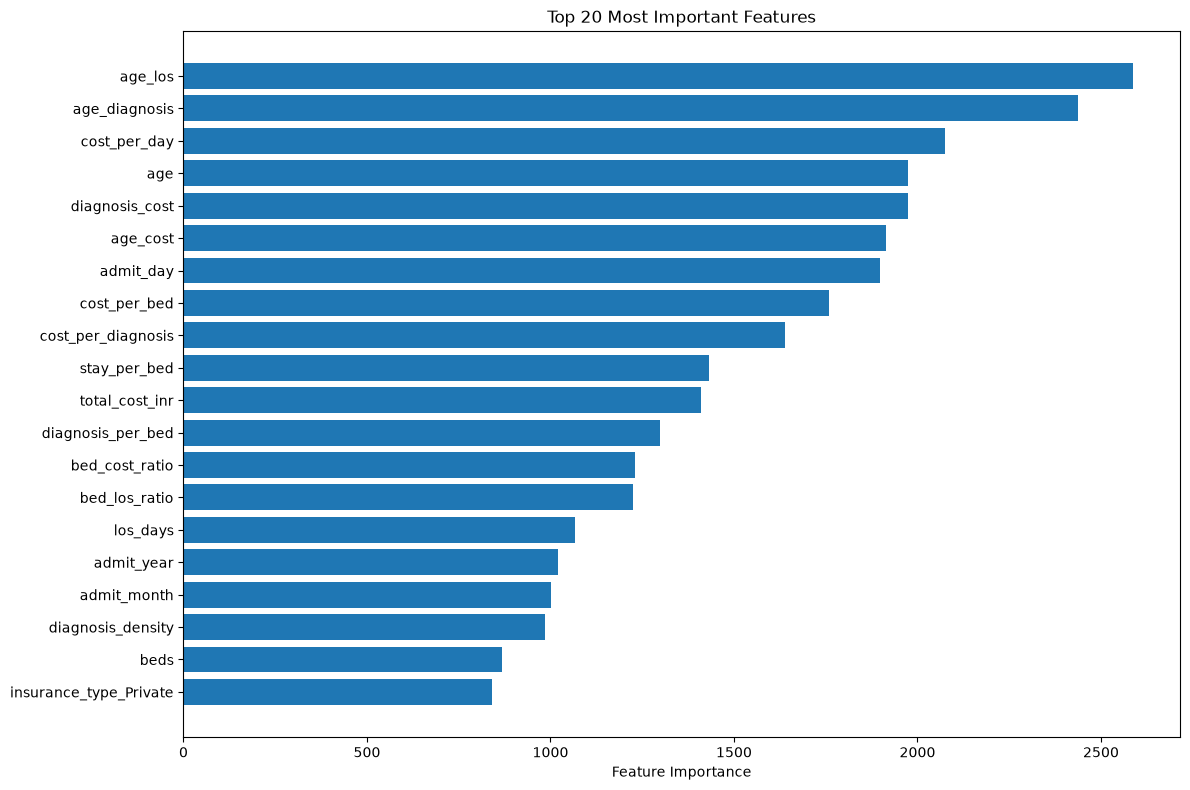

In [40]:
import matplotlib.pyplot as plt
importance_top20 = importance.head(20)

plt.figure(figsize=(12,8))

plt.barh(
    importance_top20["Feature"][::-1],
    importance_top20["Importance"][::-1]
)

plt.xlabel("Feature Importance")
plt.title("Top 20 Most Important Features")
plt.tight_layout()
plt.show()

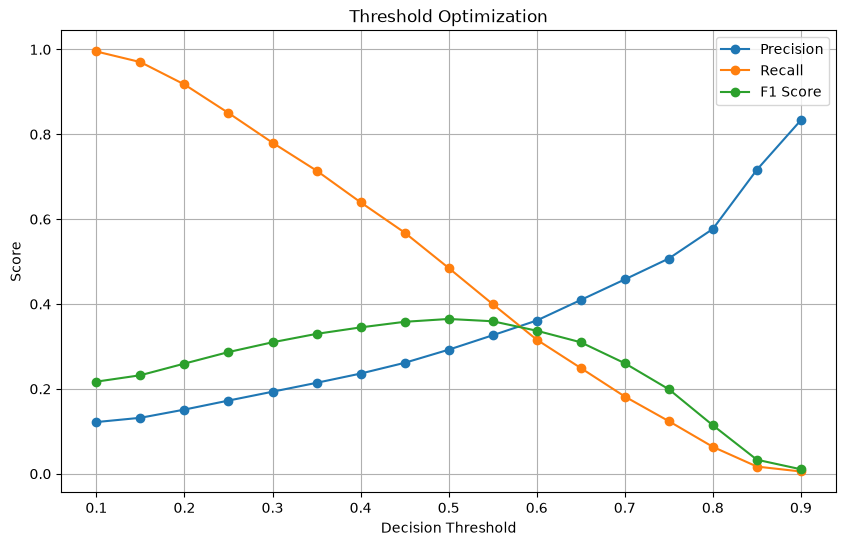

In [41]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.plot(
    threshold_results["Threshold"],
    threshold_results["Precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    threshold_results["Threshold"],
    threshold_results["Recall"],
    marker="o",
    label="Recall"
)

plt.plot(
    threshold_results["Threshold"],
    threshold_results["F1 Score"],
    marker="o",
    label="F1 Score"
)

plt.xlabel("Decision Threshold")

plt.ylabel("Score")

plt.title("Threshold Optimization")

plt.legend()

plt.grid(True)

plt.show()

In [42]:
from imblearn.over_sampling import SMOTE
from collections import Counter

smote = SMOTE(
    sampling_strategy="auto",
    random_state=42
)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_processed,
    y_train
)

print("Original Training Distribution")
print(Counter(y_train))

print("\nAfter SMOTE")
print(Counter(y_train_smote))

Original Training Distribution
Counter({0: 84632, 1: 11368})

After SMOTE
Counter({0: 84632, 1: 84632})


In [43]:
from lightgbm import LGBMClassifier

lgbm_smote = LGBMClassifier(

    learning_rate=0.01,

    max_depth=8,

    min_child_samples=30,

    n_estimators=200,

    num_leaves=63,

    subsample=0.9,

    colsample_bytree=1.0,

    random_state=42,

    n_jobs=-1

)

lgbm_smote.fit(
    X_train_smote,
    y_train_smote
)

print("LightGBM trained successfully on SMOTE data.")

[LightGBM] [Info] Number of positive: 84632, number of negative: 84632
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.147214 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 28890
[LightGBM] [Info] Number of data points in the train set: 169264, number of used features: 114
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
LightGBM trained successfully on SMOTE data.


In [44]:
smote_predictions = lgbm_smote.predict(X_test_processed)

smote_probabilities = lgbm_smote.predict_proba(X_test_processed)[:, 1]

In [45]:
print("LIGHTGBM + SMOTE RESULTS")
print(f"Accuracy : {accuracy_score(y_test, smote_predictions):.4f}")
print(f"Precision: {precision_score(y_test, smote_predictions):.4f}")
print(f"Recall   : {recall_score(y_test, smote_predictions):.4f}")
print(f"F1 Score : {f1_score(y_test, smote_predictions):.4f}")
print(f"ROC AUC  : {roc_auc_score(y_test, smote_probabilities):.4f}")

print("\nConfusion Matrix")
print(confusion_matrix(y_test, smote_predictions))

print("\nClassification Report")
print(classification_report(y_test, smote_predictions))

LIGHTGBM + SMOTE RESULTS
Accuracy : 0.8780
Precision: 0.4596
Recall   : 0.1703
F1 Score : 0.2485
ROC AUC  : 0.7397

Confusion Matrix
[[20589   569]
 [ 2358   484]]

Classification Report
              precision    recall  f1-score   support

           0       0.90      0.97      0.93     21158
           1       0.46      0.17      0.25      2842

    accuracy                           0.88     24000
   macro avg       0.68      0.57      0.59     24000
weighted avg       0.85      0.88      0.85     24000



In [48]:
comparison = pd.DataFrame({

    "Model":[

        "Logistic Regression",
        "Random Forest",
        "XGBoost",
        "LightGBM",
        "Tuned LightGBM",
        "Final LightGBM (Optimal Threshold)",
        "LightGBM + SMOTE"

    ],

    "Accuracy":[

        accuracy_score(y_test, lr_predictions),
        accuracy_score(y_test, rf_predictions),
        accuracy_score(y_test, xgb_predictions),
        accuracy_score(y_test, lgbm_predictions),
        accuracy_score(y_test, best_predictions),
        accuracy_score(y_test, final_predictions),
        accuracy_score(y_test, smote_predictions)

    ],

    "Precision":[

        precision_score(y_test, lr_predictions),
        precision_score(y_test, rf_predictions),
        precision_score(y_test, xgb_predictions),
        precision_score(y_test, lgbm_predictions),
        precision_score(y_test, best_predictions),
        precision_score(y_test, final_predictions),
        precision_score(y_test, smote_predictions)

    ],

    "Recall":[

        recall_score(y_test, lr_predictions),
        recall_score(y_test, rf_predictions),
        recall_score(y_test, xgb_predictions),
        recall_score(y_test, lgbm_predictions),
        recall_score(y_test, best_predictions),
        recall_score(y_test, final_predictions),
        recall_score(y_test, smote_predictions)

    ],

    "F1 Score":[

        f1_score(y_test, lr_predictions),
        f1_score(y_test, rf_predictions),
        f1_score(y_test, xgb_predictions),
        f1_score(y_test, lgbm_predictions),
        f1_score(y_test, best_predictions),
        f1_score(y_test, final_predictions),
        f1_score(y_test, smote_predictions)

    ],

    "ROC AUC":[

        roc_auc_score(y_test, lr_probabilities),
        roc_auc_score(y_test, rf_probabilities),
        roc_auc_score(y_test, xgb_probabilities),
        roc_auc_score(y_test, lgbm_probabilities),
        roc_auc_score(y_test, best_probabilities),
        roc_auc_score(y_test, best_probabilities),
        roc_auc_score(y_test, smote_probabilities)

    ]

})

comparison = comparison.round(4)

comparison


,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Logistic Regression,0.8840,0.6183,0.0524,0.0967,0.7487
1,Random Forest,0.8739,0.4245,0.1830,0.2557,0.7295
2,XGBoost,0.7319,0.2450,0.6073,0.3491,0.7411
3,LightGBM,0.7150,0.2382,0.6400,0.3472,0.7438
4,Tuned LightGBM,0.8000,0.2923,0.4849,0.3647,0.7459
5,Final LightGBM (Optimal Threshold),0.8000,0.2923,0.4849,0.3647,0.7459
6,LightGBM + SMOTE,0.8780,0.4596,0.1703,0.2485,0.7397


In [49]:
comparison.to_csv(
    "../results/model_comparison.csv",
    index=False
)

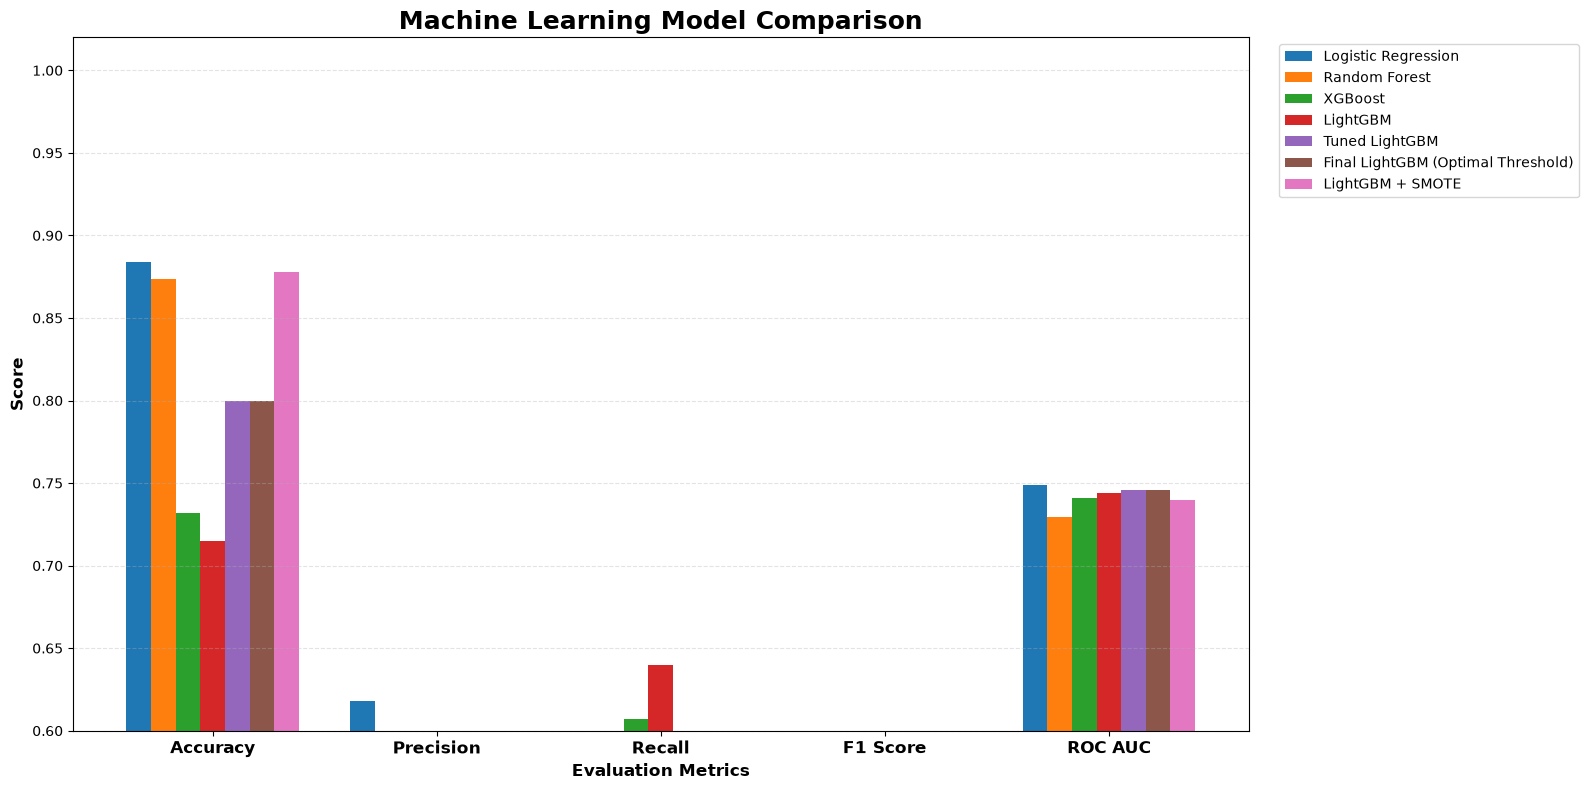

In [51]:
import matplotlib.pyplot as plt
import numpy as np

metrics = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1 Score",
    "ROC AUC"
]

models = comparison["Model"]

x = np.arange(len(metrics))

width = 0.11

plt.figure(figsize=(16,8))

for i, model in enumerate(models):

    plt.bar(
        x + i*width,
        comparison.loc[i, metrics],
        width=width,
        label=model
    )

plt.xticks(
    x + width*3,
    metrics,
    fontsize=12,
    fontweight="bold"
)

plt.ylabel(
    "Score",
    fontsize=12,
    fontweight="bold"
)

plt.xlabel(
    "Evaluation Metrics",
    fontsize=12,
    fontweight="bold"
)

plt.title(
    "Machine Learning Model Comparison",
    fontsize=18,
    fontweight="bold"
)

plt.ylim(0.60,1.02)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.35
)

plt.legend(
    bbox_to_anchor=(1.02,1),
    loc="upper left"
)

plt.tight_layout()

plt.savefig(
    "../results/model_comparison.png",
    dpi=400,
    bbox_inches="tight"
)

plt.show()

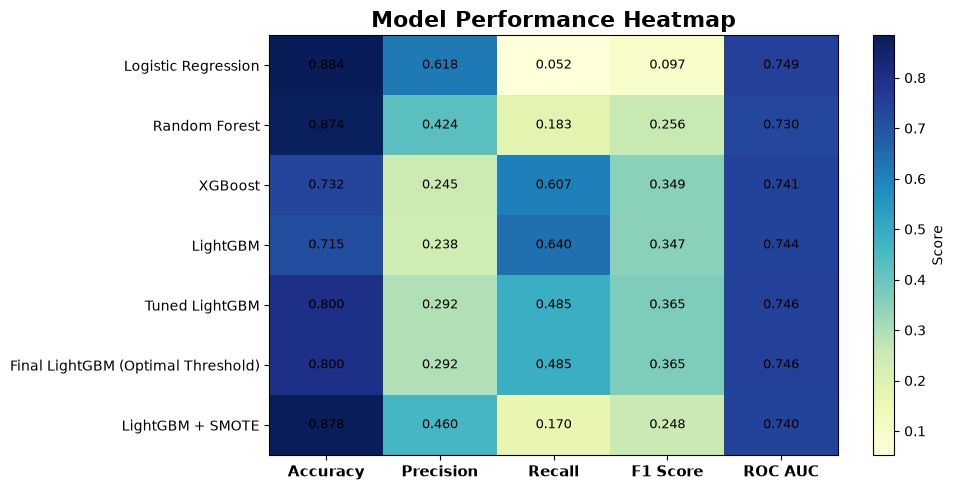

In [53]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.imshow(
    comparison.iloc[:,1:],
    aspect="auto",
    cmap="YlGnBu"
)

plt.xticks(
    range(5),
    comparison.columns[1:],
    fontsize=11,
    fontweight="bold"
)

plt.yticks(
    range(len(comparison)),
    comparison["Model"],
    fontsize=10
)

for i in range(len(comparison)):
    for j in range(5):

        plt.text(
            j,
            i,
            f"{comparison.iloc[i,j+1]:.3f}",
            ha="center",
            va="center",
            fontsize=9
        )

plt.colorbar(label="Score")

plt.title(
    "Model Performance Heatmap",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()

plt.savefig(
    "../results/model_heatmap.png",
    dpi=400,
    bbox_inches="tight"
)

plt.show()